# Hebbian model -- learning dynamics exploration

In [24]:
import pandas as pd
import numpy as np
from experimental_setups import hebbian_model

error_data = []
num_epochs = 10

for alpha in np.linspace(0.05,1,30):
    print(f'Now training Hebbian model with alpha={alpha:.2f}...')
    error_data += hebbian_model.run_hebbian_experiment(num_epochs, alpha)
    print('\t...finished!\n')

error_data = pd.concat(error_data,axis=0)
error_data.to_csv('data/hebbian_alpha_experiment.csv')

Now training Hebbian model with alpha=0.05...
	...finished!
Now training Hebbian model with alpha=0.08...
	...finished!
Now training Hebbian model with alpha=0.12...
	...finished!
Now training Hebbian model with alpha=0.15...
	...finished!
Now training Hebbian model with alpha=0.18...
	...finished!
Now training Hebbian model with alpha=0.21...
	...finished!
Now training Hebbian model with alpha=0.25...
	...finished!
Now training Hebbian model with alpha=0.28...
	...finished!
Now training Hebbian model with alpha=0.31...
	...finished!
Now training Hebbian model with alpha=0.34...
	...finished!
Now training Hebbian model with alpha=0.38...
	...finished!
Now training Hebbian model with alpha=0.41...
	...finished!
Now training Hebbian model with alpha=0.44...
	...finished!
Now training Hebbian model with alpha=0.48...
	...finished!
Now training Hebbian model with alpha=0.51...
	...finished!
Now training Hebbian model with alpha=0.54...
	...finished!
Now training Hebbian model with alpha=0.

In [25]:
errs_alpha_interleaved = error_data
errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['alpha']==0.05]
errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['condition']=='interleaved']
errs_alpha_interleaved = errs_alpha_interleaved['acc'].mean()

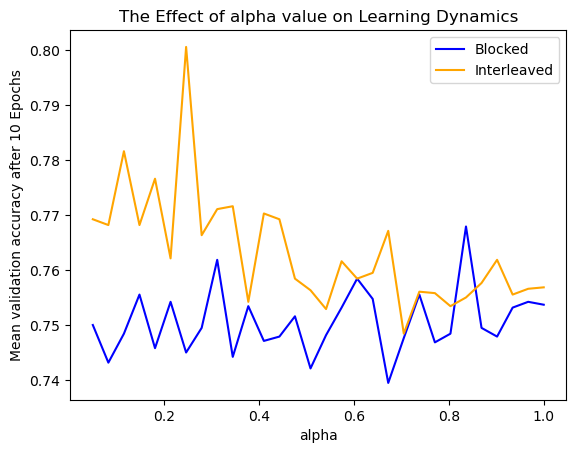

In [26]:
import matplotlib.pyplot as plt

mean_accs_blocked, mean_accs_interleaved = [], []
for alpha in np.linspace(0.05,1,30):
    errs_alpha_blocked = error_data
    errs_alpha_blocked = errs_alpha_blocked[errs_alpha_blocked['alpha']==alpha]
    errs_alpha_blocked = errs_alpha_blocked[errs_alpha_blocked['condition']=='blocked']
    errs_alpha_blocked = errs_alpha_blocked['acc'].mean()

    errs_alpha_interleaved = error_data
    errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['alpha']==alpha]
    errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['condition']=='interleaved']
    errs_alpha_interleaved = errs_alpha_interleaved['acc'].mean()

    mean_accs_blocked.append(errs_alpha_blocked)
    mean_accs_interleaved.append(errs_alpha_interleaved)

plt.plot(np.linspace(0.05,1,30), mean_accs_blocked, color='blue', label='Blocked')
plt.plot(np.linspace(0.05,1,30), mean_accs_interleaved, color='orange', label='Interleaved')

plt.title('The Effect of alpha value on Learning Dynamics')
plt.legend()
plt.xlabel('alpha')
plt.ylabel(f'Mean validation accuracy after {num_epochs} Epochs')

plt.show()